# *ASSIGNMENT-2: Network robustness*

In [3]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from itertools import combinations

In [4]:
BASE_DIR = Path().resolve().parent.parent
DATASET_PATH = BASE_DIR / "data" / "anime_info.csv"
df = pd.read_csv(DATASET_PATH)

In [5]:
filtered = df[
    (df["members"] >= 50000)
    & (df["genres"].notna())
].drop_duplicates(subset="mal_id")

G = nx.Graph()

for _, row in filtered.iterrows():
    G.add_node(row["mal_id"], title=row["title"])

for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
    genres_a = set(str(a["genres"]).split("|"))
    genres_b = set(str(b["genres"]).split("|"))

    if len(genres_a & genres_b) >= 2:
        G.add_edge(a["mal_id"], b["mal_id"])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 3579
Edges: 780393


In [6]:
def giant_component(G):
    if G.number_of_nodes() == 0:
        return 0, G

    largest = max(nx.connected_components(G), key=len)
    return len(largest), G.subgraph(largest).copy()

In [7]:
def attack(G, strategy, step=0.05):
    G = G.copy()
    N = G.number_of_nodes()
    results = []
    while G.number_of_nodes() > 0:
        remove_number = min(max(1, int(G.number_of_nodes() * step)), G.number_of_nodes())

        if strategy == "random":
            nodes = random.sample(list(G.nodes()), remove_number)

        elif strategy == "degree":
            nodes = [
                n for n, d in
                sorted(G.degree(), key=lambda x: x[1], reverse=True)[:remove_number]
            ]

        elif strategy == "pagerank":
            pr = nx.pagerank(G)
            nodes = sorted(pr, key=pr.get, reverse=True)[:remove_number]

        elif strategy == "betweenness":
            k = min(500, G.number_of_nodes())
            bc = nx.betweenness_centrality(G, k=k)
            nodes = sorted(bc, key=bc.get, reverse=True)[:remove_number]

        G.remove_nodes_from(nodes)
        size, G = giant_component(G)
        results.append(size / N)
    return results

In [8]:
def critical_threshold(G):
    degrees = [d for _, d in G.degree()]
    k1 = sum(degrees) / len(degrees)
    k2 = sum(d*d for d in degrees) / len(degrees)
    fc = 1 - 1 / ((k2 / k1) - 1)
    return k1, k2, fc

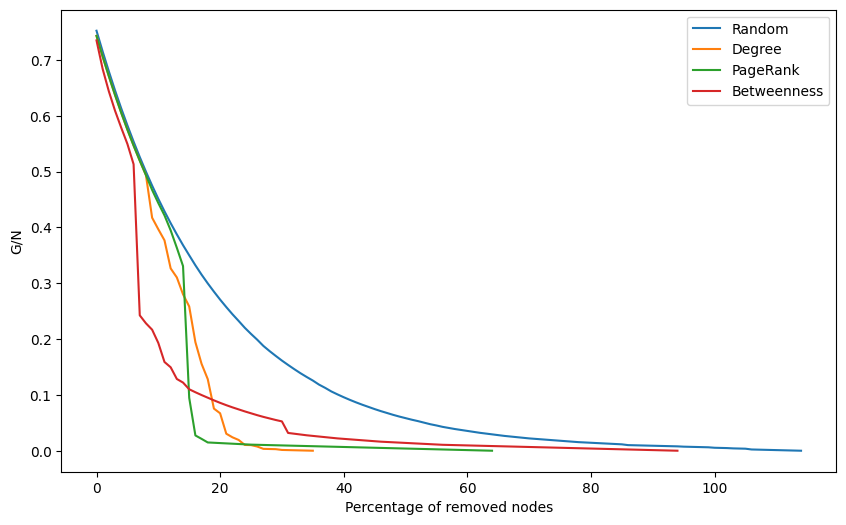

In [9]:
random_result = attack(G, "random")
degree_result = attack(G, "degree")
pagerank_result = attack(G, "pagerank")
betweenness_result = attack(G, "betweenness")

plt.figure(figsize=(10,6))

plt.plot(random_result, label="Random")
plt.plot(degree_result, label="Degree")
plt.plot(pagerank_result, label="PageRank")
plt.plot(betweenness_result, label="Betweenness")

plt.xlabel("Percentage of removed nodes")
plt.ylabel("G/N")
plt.legend()

plt.show()

## Improved

In [ ]:
G_improved = G.copy()
top_nodes = sorted(
    G_improved.degree(),
    key=lambda x: x[1],
    reverse=True
)[:3]

for node, degree in top_nodes:
    neighbors = list(G_improved.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not G_improved.has_edge(neighbors[i], neighbors[j]):
                G_improved.add_edge(neighbors[i], neighbors[j])

print("Nodes:", G_improved.number_of_nodes())
print("Edges:", G_improved.number_of_edges())

Nodes: 3579
Edges: 1720329


In [11]:
k1, k2, fc = critical_threshold(G_improved)

print("First moment:", k1)
print("Second moment:", k2)
print("Critical threshold:", fc)

First moment: 961.3461860854987
Second moment: 1656735.8178262084
Critical threshold: 0.9994193978693648


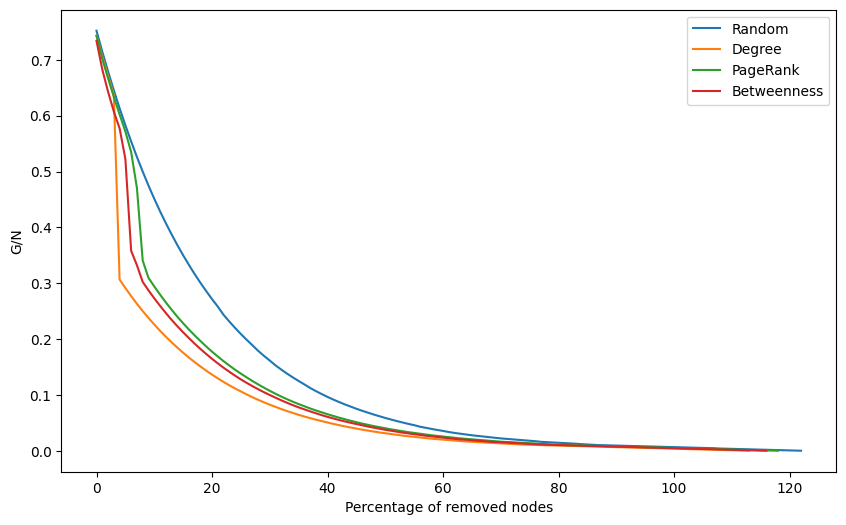

In [ ]:
random_result = attack(G_improved, "random")
degree_result = attack(G_improved, "degree")
pagerank_result = attack(G_improved, "pagerank")
betweenness_result = attack(G_improved, "betweenness")

plt.figure(figsize=(10,6))

plt.plot(random_result, label="Random")
plt.plot(degree_result, label="Degree")
plt.plot(pagerank_result, label="PageRank")
plt.plot(betweenness_result, label="Betweenness")

plt.xlabel("Percentage of removed nodes")
plt.ylabel("G/N")
plt.legend()

plt.show()

In [14]:
G_betweenness = G.copy()

bc = nx.betweenness_centrality(G_betweenness)
top_nodes = sorted(bc, key=bc.get, reverse=True)[:3]

for node in top_nodes:

    neighbors = list(G_betweenness.neighbors(node))

    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):

            if not G_betweenness.has_edge(neighbors[i], neighbors[j]):
                G_betweenness.add_edge(neighbors[i], neighbors[j])

print("Nodes:", G_betweenness.number_of_nodes())
print("Edges:", G_betweenness.number_of_edges())

k1, k2, fc = critical_threshold(G_betweenness)

print("First moment:", k1)
print("Second moment:", k2)
print("Critical threshold:", fc)

Nodes: 3579
Edges: 2268061
First moment: 1267.427214305672
Second moment: 2577432.2106733723
Critical threshold: 0.9995080178013287
